In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI:  869487064334989

In [2]:
#01-07-2026 . 02-07-2026
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\IAK91F.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1509 non-null   str  
 1   Message  1509 non-null   str  
 2   Status   1509 non-null   str  
dtypes: str(3)
memory usage: 35.5 KB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    1484
0x252514      25
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1509 non-null   str  
 1   Message  1509 non-null   str  
 2   Status   1509 non-null   str  
 3   Headers  1509 non-null   str  
dtypes: str(4)
memory usage: 47.3 KB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1509 entries, 0 to 1508
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             1509 non-null   str  
 1   Message             1509 non-null   str  
 2   Status              1509 non-null   str  
 3   Headers             1509 non-null   str  
 4   Odometer in meters  1509 non-null   int64
 5   Date                1509 non-null   str  
 6   Raw data            1509 non-null   str  
dtypes: int64(1), str(6)
memory usage: 94.3 KB
None


260701012610 -> 0 -> 3795415.0 -> 0x25251300598CA90869487064334989001EFFFF2D000000304600000007000020000000FFFFFFFFFFFFFFFFFFFF00D50039E9D70026070101261066D6C644BA3397C2A400C8400100002003951303FFFFFF00001F000AFFFFFF
260701012922 -> 1 -> 3795518.0 -> 0x25251300598CAA0869487064334989001EFFFF2D000000334A00000007000020000000FFFFFFFFFFFFFFFFFFFF00D50039EA3E00260701012922CD9CC244E63397C265FBC740001000B903951303FFFFFF00001F0001FFFFFF
260701014731 -> 2 -> 3795545.0 -> 0x25251300598CAB0869487064334989001EFFFF2D000000334A00000007000020000000FFFFFFFFFFFFFFFFFFFF00D50039EA5900260701014731CD6CC144E83397C209FBC7400120000703951300FFFFFF00001E0001FFFFFF
260701014741 -> 3 -> 3795556.0 -> 0x25251300598CAC0869487064334989001EFFFF2D000000334A00000007000020000000FFFFFFFFFFFFFFFFFFFF00D50039EA6400260701014741CD8CBE44E33397C239FAC740011000BF03951300FFFFFF00001F0001FFFFFF
260701014805 -> 4 -> 3795588.0 -> 0x25251300598CAD0869487064334989001EFFFF2D000000334700000007000020000000FFFFFFFFFFFFFFFFFFFF00D50039EA8400

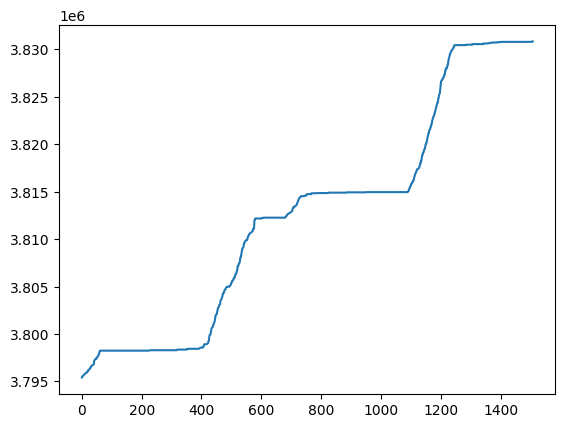

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

In [7]:
y_axis_sr=[]
x_axis_sr=[]
date_sr=[]
raw_data_sr=[]
speed_sr=[]
bottom_lim=3811298-600
upper_lim=3811298+800
unit.info()

for i in range(0,unit.shape[0]):
    #print(unit.iloc[i,4],'->',bottom_lim,'->',upper_lim)
    if unit.iloc[i,4]>bottom_lim and unit.iloc[i,4]<upper_lim:
        y_axis_sr.append(float(unit.iloc[i,4]))
        x_axis_sr.append(i)
        date_sr.append(unit.iloc[i,3])
        raw_data_sr.append(unit.iloc[i,2])
        speed_sr.append(int(unit.iloc[i,2][142:145]))  
        print(bottom_lim,'->',unit.iloc[i,4],'->',upper_lim,'->',unit.iloc[i,2][142:145])

report_highspeed_sr=pd.DataFrame()
report_highspeed_sr['Date']=date_sr
report_highspeed_sr['Raw data']=raw_data_sr
report_highspeed_sr['Speed']=speed_sr
report_highspeed_sr['odometer']=y_axis_sr

report_highspeed_sr.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\869487064334989_1.csv')

<class 'pandas.DataFrame'>
Index: 1509 entries, 0 to 1508
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             1509 non-null   str  
 1   Message             1509 non-null   str  
 2   Status              1509 non-null   str  
 3   Headers             1509 non-null   str  
 4   Odometer in meters  1509 non-null   int64
 5   Date                1509 non-null   str  
 6   Raw data            1509 non-null   str  
dtypes: int64(1), str(6)
memory usage: 94.3 KB
3810698 -> 3810723 -> 3812098 -> 024
3810698 -> 3810763 -> 3812098 -> 011
3810698 -> 3810775 -> 3812098 -> 014
3810698 -> 3810809 -> 3812098 -> 011
3810698 -> 3810862 -> 3812098 -> 027
3810698 -> 3811047 -> 3812098 -> 015
3810698 -> 3811051 -> 3812098 -> 016
3810698 -> 3811060 -> 3812098 -> 017
3810698 -> 3811066 -> 3812098 -> 025
3810698 -> 3811298 -> 3812098 -> 177
3810698 -> 3811959 -> 3812098 -> 021
3810698 -> 3812009 -> 3812098 -> 

Speed

In [8]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)
    except:
        pass 
    
unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1477 entries, 0 to 1453
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     1477 non-null   int64
 1   Date      1477 non-null   str  
 2   Raw data  1477 non-null   str  
dtypes: int64(1), str(2)
memory usage: 46.2 KB
None


260701200033 -> 558 -> 177.0 -> 0x25251300598EE30869487064334989001EFFFF2D000000444500000007000020000000FFFFFFFFFFFFFFFFFFFF00D5003A27E200260701200033CDBCBD44B03397C208EFC740177000A703951306FFFFFF0000210003FFFFFF


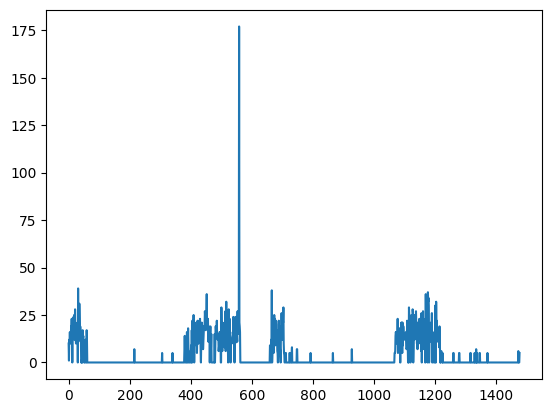

In [9]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]
date_report=[]
x_axis_report=[]
y_axis_report=[]
raw_data_report=[]
report_higspeed=pd.DataFrame()

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #print(raw_data_[i])
    
for i in range(0,len(speed)):
    if (y_axis[i]>55):
        date_report.append(date[i])
        x_axis_report.append(x_axis[i])
        y_axis_report.append(y_axis[i])
        raw_data_report.append(raw_data_[i])
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

report_higspeed['Date']=date_report
report_higspeed['Index']=x_axis_report
report_higspeed['Speed']=y_axis_report  
report_higspeed['Raw data']=raw_data_report

report_higspeed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\IAK91F_highspeed.csv')
plt.plot(x_axis,y_axis)



Satellites

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 1509 entries, 0 to 1508
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         1509 non-null   str  
 1   Message                         1509 non-null   str  
 2   Status                          1509 non-null   str  
 3   Headers                         1509 non-null   str  
 4   Satellites                      1509 non-null   int64
 5   Satellite_connection_indicator  1509 non-null   int64
 6   Raw data                        1509 non-null   str  
 7   date                            1509 non-null   str  
dtypes: int64(2), str(6)
memory usage: 106.1 KB
2026-07-01 11:25:02.194 -> 0 -> 0 -> 0x25251300598CFF0869487064334989001EFFFF2D0000002C0000000007000061000000FFFFFFFFFFFFFFFFFFFF00D50039F4E30026070111253782DC0065080CCE0161B6003700E900E703941452FFFFFF00001BFFFFFFFFFF
2026-07-01 11:25:32.966 -> 0 -> 0 -> 0x25251300598D000

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [11]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 1509 entries, 0 to 1421
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1509 non-null   str  
 1   Message  1509 non-null   str  
 2   Status   1509 non-null   str  
 3   Headers  1509 non-null   str  
dtypes: str(4)
memory usage: 58.9 KB


Power

In [12]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 1509 entries, 0 to 1421
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1509 non-null   str  
 1   Message  1509 non-null   str  
 2   Status   1509 non-null   str  
 3   Headers  1509 non-null   str  
dtypes: str(4)
memory usage: 58.9 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [13]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 1509 entries, 0 to 1421
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1509 non-null   str  
 1   Message  1509 non-null   str  
 2   Status   1509 non-null   str  
 3   Headers  1509 non-null   str  
dtypes: str(4)
memory usage: 58.9 KB
len aux_cad:  1509
